# PERGUNTA A

In [1]:
import pandas as pd
import numpy as np
from math import *
from pyproj import Transformer
from datetime import datetime , timedelta
import matplotlib.pyplot as plt
import matplotlib.dates as md

pd.set_option("display.float_format", "{:.10f}".format)

## Coordenadas Elipsoidais para Cartesianas ##

Em baixo encontram-se fórmulas gerais que permite passar de um referencial elipsoidal para um referencial cartesiano.
Basta substituir os parâmetros pelos do elipsoide WGS84.

$$ X = (v + h) * cos (\phi) * cos (\lambda) $$

$$ Y = (v + h) * cos (\phi) * sin (\lambda) $$

$$ Z = [v * (1 - e^2) + h] * sin (\phi) $$

com $$v = a / (sqrt(1-e^{2} * sin^{2} (\phi))), \quad a = 6 378 137 m \quad e^{2} = 6,694 379 990 14 × 10^{−3} $$

Link: https://www.quora.com/How-does-the-WGS-84-coordinate-system-work-in-layman-s-terms

## Using Transformer from pyproj ##

Check: https://epsg.io/4979 (EPSG:4979 Geocêntrico e Elipsoidal) and https://epsg.io/4978 (EPGS:4978 Geocêntrico e Cartesiano)

Para usar a biblioteca pyproj: https://stackoverflow.com/questions/1185408/converting-from-longitude-latitude-to-cartesian-coordinates


In [2]:


def wgs84_latlonh_to_xyz(lon,lat,h):

    a=6378137.0             #radius a of earth in meters cfr WGS84
    b=6356752.3             #radius b of earth in meters cfr WGS84
    e2=1-(b**2/a**2)        #squared excentricity
    latr=lat/90*0.5*pi      #latitude in radians
    lonr=lon/180*pi         #longituede in radians
    Nphi=a/sqrt(1-e2*sin(latr)**2)
    x=(Nphi+h)*cos(latr)*cos(lonr)
    y=(Nphi+h)*cos(latr)*sin(lonr)
    z=(b**2/a**2*Nphi+h)*sin(latr)
    return([x,y,z])

print('Elipsoidal Formula: ', wgs84_latlonh_to_xyz(110. , -40. , 10))

### Or ... ###

lon, lat, hgt = 110., -40., 10 # Longitude, Latitude, Altitude
llh_to_xyz = Transformer.from_crs("EPSG:4979", "EPSG:4978", always_xy=True)

print('Using Transformer from pyproj: ', llh_to_xyz.transform(lon, lat, hgt))

Elipsoidal Formula:  [-1673407.1761970674, 4597648.430154765, -4077991.985560293]
Using Transformer from pyproj:  (-1673407.174653753, 4597648.425914545, -4077992.0000764728)


Vemos que os valores são bastante semelhantes com erros apenas a começar nas casas das centésimas, contudo verificando com ferramentas implementadas online, concluímos para obter uma maior precisão é melhor utilizar o método Transformer da biblioteca pyproj.

Agora que definimos/escolhemos o conversor de coordenadas podemos começar a responder aos itens do enunciado.

## Pergunta 1 
Utilizando a metodologia descrita no documento EV – Avaliação da exatidão de um sistema GNSS – 2025-2026.pdf, considerando 𝜉 = 10, determinem o 
erro de posição horizontal, 𝑑, e o erro de posição vertical, ℎ, para cada uma das seguintes soluções de navegação. Nota: apresentem as coordenadas, expressas em metros (𝑚), dos vários pontos no ref. cartesiano considerado. 

Solução de navegação A 

- *Lon_A* -9.19496103°  W 
- *Lat_A* 38.80482050°  N 
- *Alt_A*     1284.221  m 

Solução de navegação B 

- *Lon_B* -9.19497203°  W 
- *Lat_B* 38.80572550°  N 
- *Alt_B*     1281.321  m 

Solução de navegação C 

- *Lon_C* -9.19497603°  W 
- *Lat_C* 38.80581050°  N 
- *Alt_C*     1280.221  m 

Solução de navegação D 

- *Lon_C* -9.19497003°  W 
- *Lat_D* 38.80562050°  N 
- *Alt_D*     1282.221  m 

Coordenadas da antena de um recetor de um sistema GNSS:
      
- *Lon_ref* -9.19497112°  W 
- *Lat_ref* 38.80572026°  N 
- *Alt_ref*    1282.192   m 


Para obter as coordenadas no referencial cartesiano:


In [3]:
# Correr para apresentar as coordenadas dos vários pontos em (m) 

data = {
    "Ponto": ["Antena", "Solução A", "Solução B", "Solução C", "Solução D"],
    "Longitude": ["-9.19497112", "-9.19496103","-9.19497203","-9.19497603","-9.19497003"],
    "Latitude": ["38.80572026", "38.80482050","38.80572550","38.80581050","38.80562050"],
    "Alt_ref": ["1282.192", "1284.221","1281.321","1280.221","1282.221"]
} 

df = pd.DataFrame(data)

df["Longitude"] = df["Longitude"].astype(float)
df["Latitude"] = df["Latitude"].astype(float)
df["Alt_ref"] = df["Alt_ref"].astype(float)

df[["X", "Y", "Z"]] = df.apply(
    lambda row: pd.Series(
        llh_to_xyz.transform(
            row["Longitude"],
            row["Latitude"],
            row["Alt_ref"]
        )
    ),
    axis=1
)

df.head() # mostra os 5 primeiros elementos

,Ponto,Longitude,Latitude,Alt_ref,X,Y,Z
0,Antena,-9.1949711200,38.8057202600,1282.1920000000,4913906.8898277665,-795436.6456129180,3976336.3193078758
1,Solução A,-9.1949610300,38.8048205000,1284.2210000000,4913970.3937151087,-795446.0372343903,3976259.7375333868
2,Solução B,-9.1949720300,38.8057255000,1281.3210000000,4913905.8472370701,-795436.5569341168,3976336.2268653247
3,Solução C,-9.1949760300,38.8058105000,1280.2210000000,4913899.1069527855,-795435.8178973533,3976342.8922341284
4,Solução D,-9.1949700300,38.8056205000,1282.2210000000,4913913.7796702292,-795437.6649710217,3976327.7056233226


Para resolver este exercício vamos criar uma função que recebe os pontos ***B*** e ***C*** e calcula os erros tal como mencionado no documento. O ponto ***A*** é a origem do referencial cartesiano a ser utilizado. ***B*** corresponde posição da antena de receção, e ***C*** a solução de navegação.

In [4]:
def get_error(xi, lon_ant, lat_ant, hgt_ant, lon, lat, hgt):

    llh_to_xyz = Transformer.from_crs("EPSG:4979", "EPSG:4978", always_xy=True)
    b = llh_to_xyz.transform(lon_ant, lat_ant, hgt_ant) #Obter as coordenadas XYZ da antena 
    c = llh_to_xyz.transform(lon, lat, hgt) #Obter as coordenas XYZ da solução GNSS 

    b = np.array(b)
    c = np.array(c)
    # r = AB = B - A = B , como A é a origem
    # s = AC = C - A = C

    r = b
    s = c
    
    # calcular o erro horizontal (para efeito de teste)
    d1 = np.linalg.norm(np.cross(s,r)) / np.linalg.norm(r)

    # Isto seria a lógica para o d, mas temos que faz considerando A' um ponto mais próximo de B e C
    # calcular os erros e retornar d_error e h_error

    al = b - xi * r / np.linalg.norm(r)

    rl = xi * r / np.linalg.norm(r)

    sl = c - al #sl = vec(A'C)

    #Erro de posição horizontal
    d2 = np.linalg.norm(np.cross(sl,rl)) / np.linalg.norm(rl)

    #Erro de posição vertical
    h = sqrt(np.linalg.norm(sl)**2 - d2**2) - np.linalg.norm(rl)

    return [d2 , h]

# Teste da função
print(get_error(10, -9.19497112, 38.80572026, 1282.192,-9.1949610300,38.8048205000,1284.2210000000 ))

[np.float64(99.90077852057989), np.float64(2.355609543002206)]



Utilizando a função `get_error(lon_ant, lat_ant, hgt_ant, lon, lat, hgt)` e iterando no dataframe:

In [5]:
df["X"] = df["X"].astype(float)
df["Y"] = df["Y"].astype(float)
df["Z"] = df["Z"].astype(float)

antena = [-9.19497112, 38.80572026, 1282.192] # lon, lat, hgt
xi = 10

df[["d_error", "h_error"]] = df.apply(
    lambda row: pd.Series(
        get_error(xi,
            antena[0], 
            antena[1], 
            antena[2],
            row["Longitude"],
            row["Latitude"],
            row["Alt_ref"]
        )
    ),
    axis=1
)

df.head()

,Ponto,Longitude,Latitude,Alt_ref,X,Y,Z,d_error,h_error
0,Antena,-9.1949711200,38.8057202600,1282.1920000000,4913906.8898277665,-795436.6456129180,3976336.3193078758,0.0000000001,-0.0000000001
1,Solução A,-9.1949610300,38.8048205000,1284.2210000000,4913970.3937151087,-795446.0372343903,3976259.7375333868,99.9007785206,2.3556095430
2,Solução B,-9.1949720300,38.8057255000,1281.3210000000,4913905.8472370701,-795436.5569341168,3976336.2268653247,0.5843345534,-0.8729020822
3,Solução C,-9.1949760300,38.8058105000,1280.2210000000,4913899.1069527855,-795435.8178973533,3976342.8922341284,10.0222884314,-2.0038338622
4,Solução D,-9.1949700300,38.8056205000,1282.2210000000,4913913.7796702292,-795437.6649710217,3976327.7056233226,11.0770175943,0.0652908892


## Pergunta 2 
No ponto 4 do presente trabalho, cuja descrição está mais à frente, é pedido 
que determinem os erros de um sistema GNSS. Utilizem a ferramenta que irão 
utilizar para determinar os erros das soluções de navegação A, B, C e D, 
anteriormente referidas. 

In [6]:
print(df[["d_error","h_error"]])

# Função que será utilizada no exercício 4

#Fórmula de Haversine para aproximar o erro horizontal
def haversine (ref_lat, ref_lon, ns_lat, ns_lon):

    lat1, lon1 = np.radians(ref_lat), np.radians(ref_lon)
    lat2, lon2 = np.radians(ns_lat), np.radians(ns_lon)
    R = 6371000

    dlat = lat2 - lat1
    dlon = lon2 - lon1 

    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    HPE1 = R * c

    return HPE1

HPE = haversine (df["Latitude"],df["Longitude"], antena[1], antena[0]) #antena[0] -> antena_longitude
VPE = df['Alt_ref'] - 1282.192

print("\nd_error_haversine\n" , HPE ,"\n\nh_error_haversine\n",VPE)


        d_error       h_error
0  0.0000000001 -0.0000000001
1 99.9007785206  2.3556095430
2  0.5843345534 -0.8729020822
3 10.0222884314 -2.0038338622
4 11.0770175943  0.0652908892

d_error_haversine
 0     0.0000000000
1   100.0525674302
2     0.5879728693
3    10.0432459996
4    11.0932079749
dtype: float64 

h_error_haversine
 0    0.0000000000
1    2.0290000000
2   -0.8710000000
3   -1.9710000000
4    0.0290000000
Name: Alt_ref, dtype: float64



## Pergunta 3 
Comparem os resultados obtidos nos pontos 1 e 2. Comentem as eventuais 
diferenças.  

R .: Vemos que o método proposto é de facto uma boa aproximação, com erros de apenas alguns centímetros, o que não é grave tendo em consideração as dimensões de uma aeronave. Contudo é notório que conforme o erro no plano horizontal aumenta, o erro vertical tende a aumentar ligeiramente, o que é de esperar, sendo que a altitude devia passar a ser medida em relação a outro referencial ortogonal com a superfície terrestre, e a reta paralela que passa pelo ponto de solução com vetor diretor da reta de referência, fica mais afastada do centro do referencial. Mas não deixa de ser uma boa aproximação.

## Pergunta 4 
Determinar os erros do sistema de navegação EGNOS, ou seja, os erros da 
solução de navegação EGNOS, no plano horizontal (Horizontal Position Error – 
HPE) e no eixo vertical (Vertical Position Error – VPE) – atenção, tanto a posição 
da aeronave, obtida a partir da solução de navegação EGNOS, como a sua 
posição “verdadeira” estão expressas no sistema de coordenadas WGS84; 


In [7]:
df = pd.read_csv("EV_2026-A24.txt" , sep = ";")

# Extração de variáveis
RX_TOM = np.array(df["RX_TOM"])            # Receiver time of measurement
RX_WEEK = np.array(df["RX_WEEK"])          # GPS week number
NSV_LOCK = np.array(df["NSV_LOCK"])        # Number of satellites available
NSV_USED = np.array(df["NSV_USED"])        # Number of satellites used
NS_HPL = np.array(df["NS_HPL"] )           # Horizontal Protection Level
NS_VPL = np.array(df["NS_VPL"] )           # Vertical Protection Level
NS_LAT = np.array(df["NS_LAT"] )           # EGNOS latitude
NS_LON= np.array(df["NS_LON"] )            # EGNOS longitude
NS_ALT = np.array(df["NS_ALT"] )           # EGNOS altitude
REF_LAT = np.array(df["REF_LAT"])          # Reference latitude
REF_LON = np.array(df["REF_LON"])          # Reference longitude
REF_ALT = np.array(df["REF_ALT"])          # Reference altitude


#Erro Horizontal
HPE = haversine(REF_LAT, REF_LON, NS_LAT, NS_LON)

#Erro Vertical
VPE = NS_ALT - REF_ALT


## Pergunta 5 

Representar graficamente, em função do tempo (RX_TOM), para o plano 
horizontal e para o eixo vertical, os erros do sistema de navegação, os limites 
de proteção e o número de satélites utilizado na geração da solução de 
navegação EGNOS; 

### Plot HPE & HPL e VPE & VPL

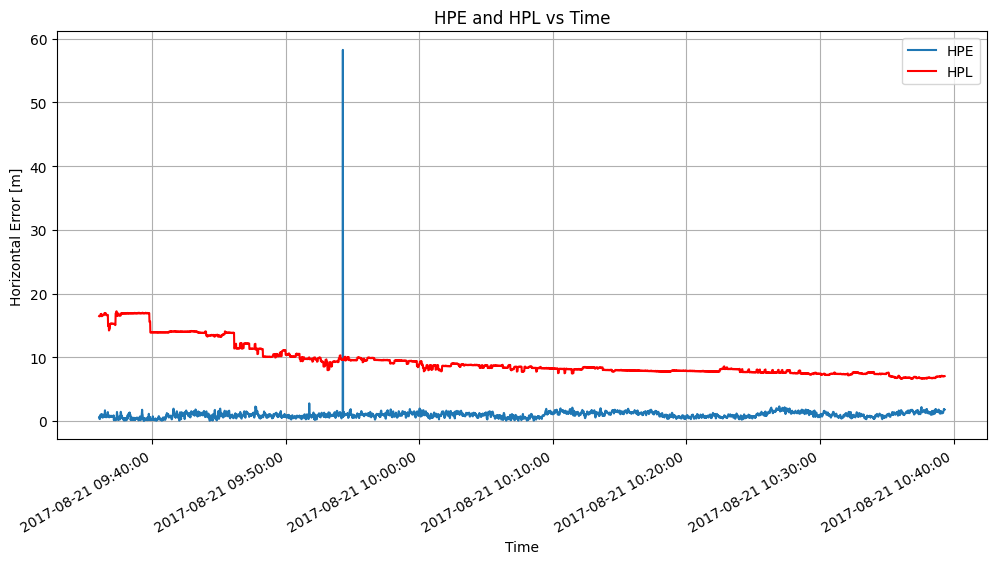

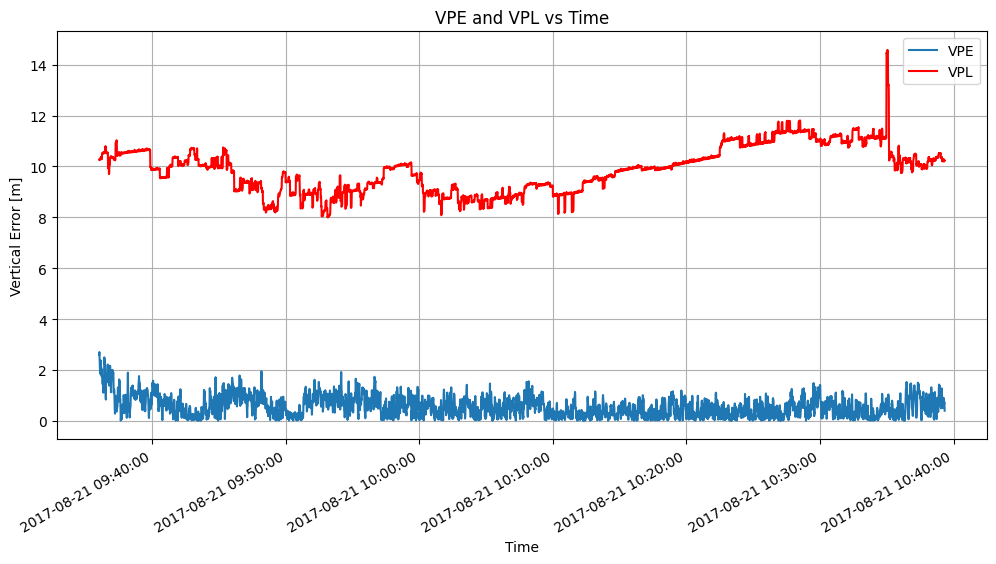

In [8]:
# Calcular a data em timestamps
Epoch = datetime(1980 , 1 , 6)
week_start = Epoch + timedelta ( weeks = 1963)
timestamps = [ week_start + timedelta ( seconds = t ) for t in df["RX_TOM"]]

def time_format():
    ax=plt.gca()
    xfmt = md.DateFormatter('%Y-%m-%d %H:%M:%S')
    ax.xaxis.set_major_formatter(xfmt)
    plt.gcf().autofmt_xdate() 
    return


# Erro Plano Horizontal
plt.figure(figsize=(12,6))
plt.plot(timestamps, HPE, label = 'HPE')
plt.plot(timestamps, NS_HPL, color = 'r', label = 'HPL')
plt.grid()
plt.legend()
plt.ylabel("Horizontal Error [m]")
plt.xlabel("Time")
plt.title('HPE and HPL vs Time')
time_format()


# Erro Plano Vertical 
VPE = [abs(x) for x in VPE] # Para poder comparar com o VPL

plt.figure(figsize=(12,6))
plt.plot(timestamps, VPE, label = 'VPE')
plt.plot(timestamps, NS_VPL, color = 'r', label = 'VPL')
plt.grid()
plt.legend()
plt.ylabel("Vertical Error [m]")
plt.xlabel("Time")
plt.title('VPE and VPL vs Time')
time_format()


### Satélites Observados e Utilizados

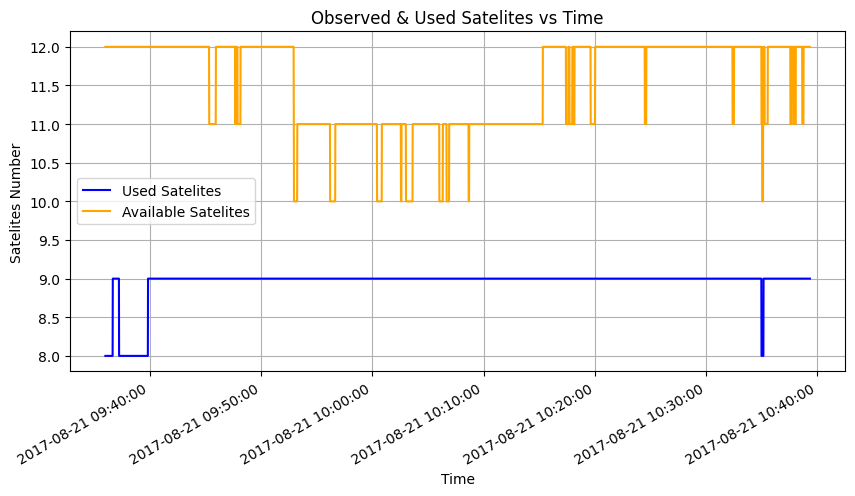

In [9]:
# Satélites Observados e Utilizados para Lock
plt.figure(figsize=(10,5))
plt.plot(timestamps, NSV_USED, color = 'b', label = 'Used Satelites')
plt.plot(timestamps, NSV_LOCK, color = 'orange', label = 'Available Satelites')
plt.grid()
plt.legend()
plt.ylabel("Satelites Number")
plt.xlabel("Time")
plt.title('Observed & Used Satelites vs Time')
time_format()

## 6.
Determinar os correspondentes parâmetros de desempenho (exatidão, integridade, disponibilidade e continuidade)

**Exatidão:**

A exatidão é quantificada pelos erros de posição horizontal 
(Horizontal Position Error – HPE) e vertical (Vertical Position Error - VPE). Os 
correspondentes percentis 95 das amostras obtidas devem verificar os seguintes 
limites:

<center>

| Modo de operação | HPE (95%) | VPE  (95%) |
| ---------------- | --------- | ---------- |
|      APV-I       |    16 m   |    20 m    |
|      APV-II      |    16 m   |    8 m     |  
|      CAT-1       |    16 m   |    5 m     | 
</center> 

In [10]:
p95_HPE = np.percentile(HPE, 95)
p95_VPE = np.percentile(VPE, 95)

print(f"HPE Percentil 95%: {p95_HPE}") 
print(f"VPE Percentil 95%: {p95_VPE}") 

HPE Percentil 95%: 1.6318055847621948
VPE Percentil 95%: 1.2610999999999672


Verifica-se que tanto o percentil de 95% do erro no plano horizontal como do plano vertical estão dentro dos limites estipulados para os três modos de operação de SBAS (APV-I, APV-II, CAT-I)

**Integridade:**

A integridade é quantificada pelos níveis de proteção  horizontal (Horizontal Protection Level – HPL), vertical (Vertical Protection Level - VPL)  e pela sua relação com os correspondentes erros de navegação. Os percentis 99 dos  níveis de proteção das amostras obtidas devem verificar os seguintes limites, definidos  como níveis de alerta horizontal (Horizontal Alert Level – HAL) e vertical (Vertical Alert Level – VAL): 

<center>

| Modo de operação |      HAL   |       VAL    |
| ---------------- | ---------  | ----------   |
|      APV-I       | 40 m       |      50 m    |
|      APV-II      | 40 m       |      20 m    |  
|      CAT-1       | 40 m       |      12 m    | 

</center>

In [11]:
p99_NS_HPL = np.percentile(NS_HPL, 99)
p99_NS_VPL = np.percentile(NS_VPL, 99)

print(f"NS_HPL Percentil 99%: {p99_NS_HPL}") 
print(f"NS_VPL Percentil 99%: {p99_NS_VPL}") 

NS_HPL Percentil 99%: 16.92
NS_VPL Percentil 99%: 11.692169999999996


Os percentis de 99% dos níveis de proteção encontram-se dentro do intervalo definido para os três modos de operação, encontrando-se então o sistema EGNOS dentro dos critérios definidos pela ICAO. Os nível de alerta horizontal definido pelo ICAO é igual para os três modos de operação, sendo de 40 m. O percentil de 99% do HPL é de 16.92 m, encontrando-se favorávelmente dentro do intervalo definido.  
Já os níveis de alerta verticais, dependem do modo de opereção. O modo mais crítico é o CAT-1, com um nível de alerta de 12 m. Contudo, o sistema EGNOS satfisfaz este requisito, com um percentil de 99% de proteção de 11.69 m, garantindo que a solução EGNOS é robusta até para os modos de operação mais críticos. 

**Disponibilidade**

A disponibilidade é definida como a percentagem de tempo, relativamente ao período de análise, em que o sistema de navegação permite um determinado modo de operação. Para o efeito, considera-se que o sistema de navegação permite um determinado modo de operação, num determinado instante de tempo, se os níveis de proteção, horizontal e vertical, forem inferiores aos correspondentes níveis de alerta, definidos anteriormente. De acordo com os requisitos impostos pelo ICAO, se a disponibilidade verificada para um determinado modo de operação for superior a 99%, o sistema de navegação por satélite poderá vir a ser adotado no correspondente modo de operação. 

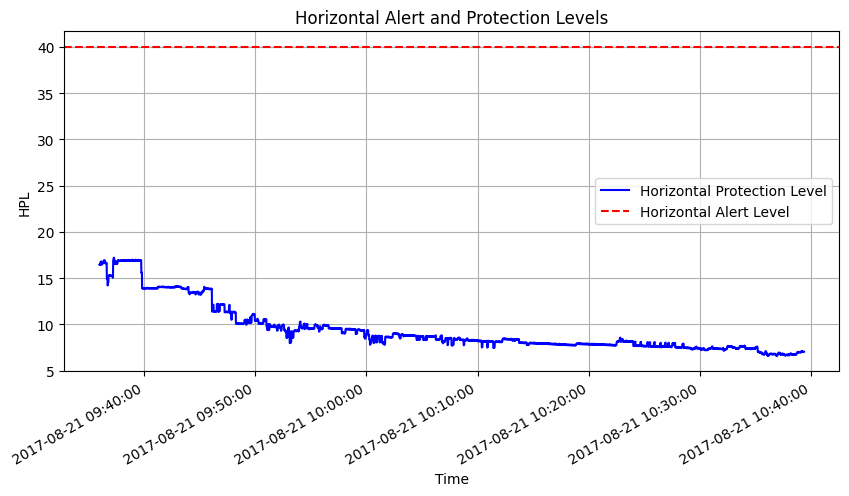

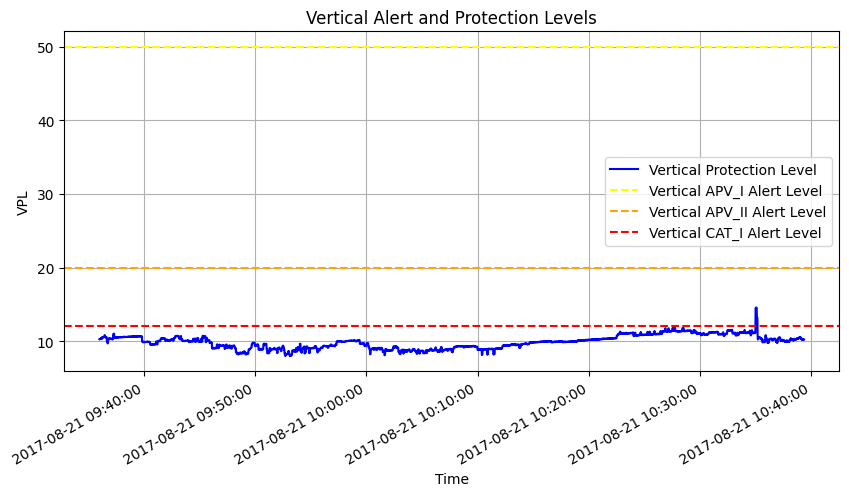

In [12]:
HAL_APV_I = 40
HAL_APV_II = 40
HAL_CAT_I = 40

VAL_APV_I = 50
VAL_APV_II = 20
VAL_CAT_I = 12

# Disponibilidade dos níveis horizontais
plt.figure(figsize=(10,5))
plt.plot(timestamps, NS_HPL, color = 'b', label = 'Horizontal Protection Level')
plt.axhline(HAL_APV_I, color = 'r', linestyle = "--", label = 'Horizontal Alert Level')
plt.grid()
plt.legend()
plt.ylabel("HPL")
plt.xlabel("Time")
plt.title('Horizontal Alert and Protection Levels')
time_format()

# Disponibilidade dos níveis verticais
plt.figure(figsize=(10,5))
plt.plot(timestamps, NS_VPL, color = 'b', label = 'Vertical Protection Level')
plt.axhline(VAL_APV_I, color = 'yellow', linestyle = "--", label = 'Vertical APV_I Alert Level')
plt.axhline(VAL_APV_II, color = 'orange', linestyle = "--", label = 'Vertical APV_II Alert Level')
plt.axhline(VAL_CAT_I, color = 'red', linestyle = "--", label = 'Vertical CAT_I Alert Level')
plt.grid()
plt.legend()
plt.ylabel("VPL")
plt.xlabel("Time")
plt.title('Vertical Alert and Protection Levels')
time_format()

In [13]:
#Função get_availability

def get_availability(RX_TOMf, HALf, VALf, HPLf, VPLf):
    t = len(RX_TOMf)
    count = 0

    for i in range(len(RX_TOMf)):
        if ((HPLf[i] < HALf) and (VPLf[i] < VALf)):
            count = count + 1

    return (count/t * 100)

APV_I_availability = get_availability(RX_TOM, HAL_APV_I, VAL_APV_I, NS_HPL, NS_VPL)
APV_II_availability = get_availability(RX_TOM, HAL_APV_II, VAL_APV_II, NS_HPL, NS_VPL)
CAT_I_availability = get_availability(RX_TOM, HAL_CAT_I, VAL_CAT_I, NS_HPL, NS_VPL)


print('APV_I_availability:', (APV_I_availability),'%')
print('APV_II_availability:', (APV_II_availability),'%')
print('CAT_I_availability:', (CAT_I_availability),'%')

APV_I_availability: 100.0 %
APV_II_availability: 100.0 %
CAT_I_availability: 99.71052631578947 %


Pela análise dos gráficos observamos que os níves de proteção para os três modos mantiveram-se bem abaixo do nível de alerta correspondente, que neste caso é o mesmo. Os níveis de proteção horizontais, para os modos APV_I e APV_II mantiveram-se abaixo dos correspondentes níveis de alerta no tempo de ensaio. Assim sendo, concluímos que estes modos demonstram uma disponibilidade de 100%.  
Contudo, o modo CAT_I quebra o limite de alerta vertical num curto período de tempo. Para calcular a disponibilidade dos modos, desenvolveu-se a função `get_availability(RX_TOMf, HALf, VALf, HPLf, VPLf)`. Utilizando esta função, verifica-se, como esperado, uma disponibilidade de 100% para os modos APV_I e APV_II. O modo CAT_I apresenta uma disponibilidade de 99.71%. De acordo com ICAO, para o sistema de navegação ser adotado num modo de operação, precisa de disponibilidade superior a 99%. Tal verifica-se para os três modos.  

**Continuidade:**

A validação da continuidade do serviço disponibilizado é feita pela contabilização dos eventos de continuidade, isto é, pela contagem dos períodos em que o sistema exibiu disponibilidade para cada um dos modos de operação. A título de exemplo, se o sistema nunca esteve disponível, o número de eventos de continuidade será 0 (zero). Caso tenha estado sempre disponível o número de eventos de continuidade será 1 (um). 

In [14]:
#Função que contabiliza os intervalos de continuidade

def get_continuity(RX_TOMf, HALf, VALf, HPLf, VPLf):
    vec = []
    for i in range(len(RX_TOMf)):
        if ((HPLf[i] >= HALf) or (VPLf[i] >= VALf)):
            vec.append(0) # Indisponível
        else:
            vec.append(1) # Disponível
    
    count = 0
    if len(vec) > 0 and vec[0] == 1:
        count = 1
        
    # Verifica transições de 0 para 1 (o sistema voltou a ficar disponível)
    for j in range(1, len(vec)):
        if vec[j] == 1 and vec[j-1] == 0:
            count += 1
            
    return count

APV_I_continuity = get_continuity(RX_TOM, HAL_APV_I, VAL_APV_I, NS_HPL, NS_VPL)
APV_II_continuity = get_continuity(RX_TOM, HAL_APV_II, VAL_APV_II, NS_HPL, NS_VPL)
CAT_I_continuity = get_continuity(RX_TOM, HAL_CAT_I, VAL_CAT_I, NS_HPL, NS_VPL)

print('APV_I_continuity:', (APV_I_continuity))
print('APV_II_continuity:', (APV_II_continuity))
print('CAT_I_continuity:', (CAT_I_continuity))

APV_I_continuity: 1
APV_II_continuity: 1
CAT_I_continuity: 2


Observa-se dos resultado que os modos de operação APV_I e APV_II encontravam-se disponíveis em todo o ensaio, sendo que possuem apenas um único intervalo de continuidade. O modo CAT_I apresenta uma interruptação de disponibilidade, que é possível observar no gráfico de Vertical Alert and Protection Levels, e portanto dois intervalos de continuidade. Também observa-se que esta interrupção de disponibilidade deve-se apenas à componente vertical da solução, sendo que a disponibilidade horizontal foi assegurada em todo o intervalo dos dados.

## 7. 
Identificar eventuais eventos de integridade, indicando todas as suas características que considerem relevantes.  
Comparando os níveis de proteção, horizontal e vertical, com os correspondentes erros de navegação, há a ocorrência de um evento de integridade se, num determinado instante de tempo, um dos níveis de proteção for inferior ao correspondente erro de navegação. Estes eventos devem ser contabilizados e identificados, para posterior análise. 

In [ ]:
# Função para checkar a integridade
def check_integrity(RX_TOM, RX_WEEK, HPEf, VPEf, HPLf, VPLf):
     
    epoch = datetime(1980, 1, 6) # Epoch GPS (06/01/1980)
    def gps_to_datetime(week, seconds):
        return [epoch + timedelta(weeks=int(w), seconds=int(s)) for w, s in zip(week, seconds)]

    timestamps = np.array(gps_to_datetime(RX_WEEK, RX_TOM))

    #Lógica de integridade vetorizada
    violation_H = HPEf > HPLf
    violation_V = VPEf > VPLf
    
    status_code = np.zeros(len(HPEf), dtype=int)
    status_code[violation_H & ~violation_V] = 1
    status_code[~violation_H & violation_V] = 2
    status_code[violation_H & violation_V] = 3
    
    indices_erro = np.where(status_code > 0)[0]
    
    print(f"Total de eventos de integridade encontrados: {len(indices_erro)}")

    print(HPEf[indices_erro])
    
    for i in indices_erro:
        motivo = {1: "Violação HPL", 2: "Violação VPL", 3: "Violação HPL e VPL"}[status_code[i]]
        print(f"Data: {timestamps[i]} | Motivo: {motivo} | HPE: {HPEf[i]} | VPE: {VPEf[i]}")
    
    return timestamps, status_code

status = check_integrity(RX_TOM, RX_WEEK, HPE, VPE, NS_HPL, NS_VPL)

Total de eventos de integridade encontrados: 1
[58.22500226]
Data: 2017-08-21 09:54:16 | Motivo: Violação HPL | HPE: 58.22500225955257 | VPE: 0.9529999999999745


Foram encontrados um total de 1 eventos de integridade. Dada a definição de evento de integridade, este é um valor satisfatório. Acontece que pelo instante 2017-08-21 09:54:16 o sistema EGNOS estimou a posição horizontal da aeronave com um erro de aproximadamente 58 m. É um erro pontual da solução, que pode dar-se devido a falhas de processamento, ruído eletromagnético ou até mesmo mecânico. 



## 8. 
Apresentar e comentar os resultados obtidos. 

R.: Esta vai respondida no relatório conforme os resultados forem apresentados. Acrescentar uma pequena conclusão da análise efetuada.